In [1]:
with open("names.txt") as f:
    names = f.read().splitlines()

In [2]:
names[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(names)

32033

In [4]:
vocab = sorted(list(set("".join(names))))
vocab.insert(0,".")

In [5]:
stoi = {v:k for k,v in enumerate(vocab)}
itos = {k:v for k,v in enumerate(vocab)}

In [6]:
import torch
from matplotlib import pyplot as plt
import numpy as np

In [7]:
N = torch.zeros(27,27)

In [8]:
for name in names:
    new_name = "."+name+"."
    for ch1,ch2 in zip(new_name[:-1],new_name[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        N[idx1,idx2] += 1

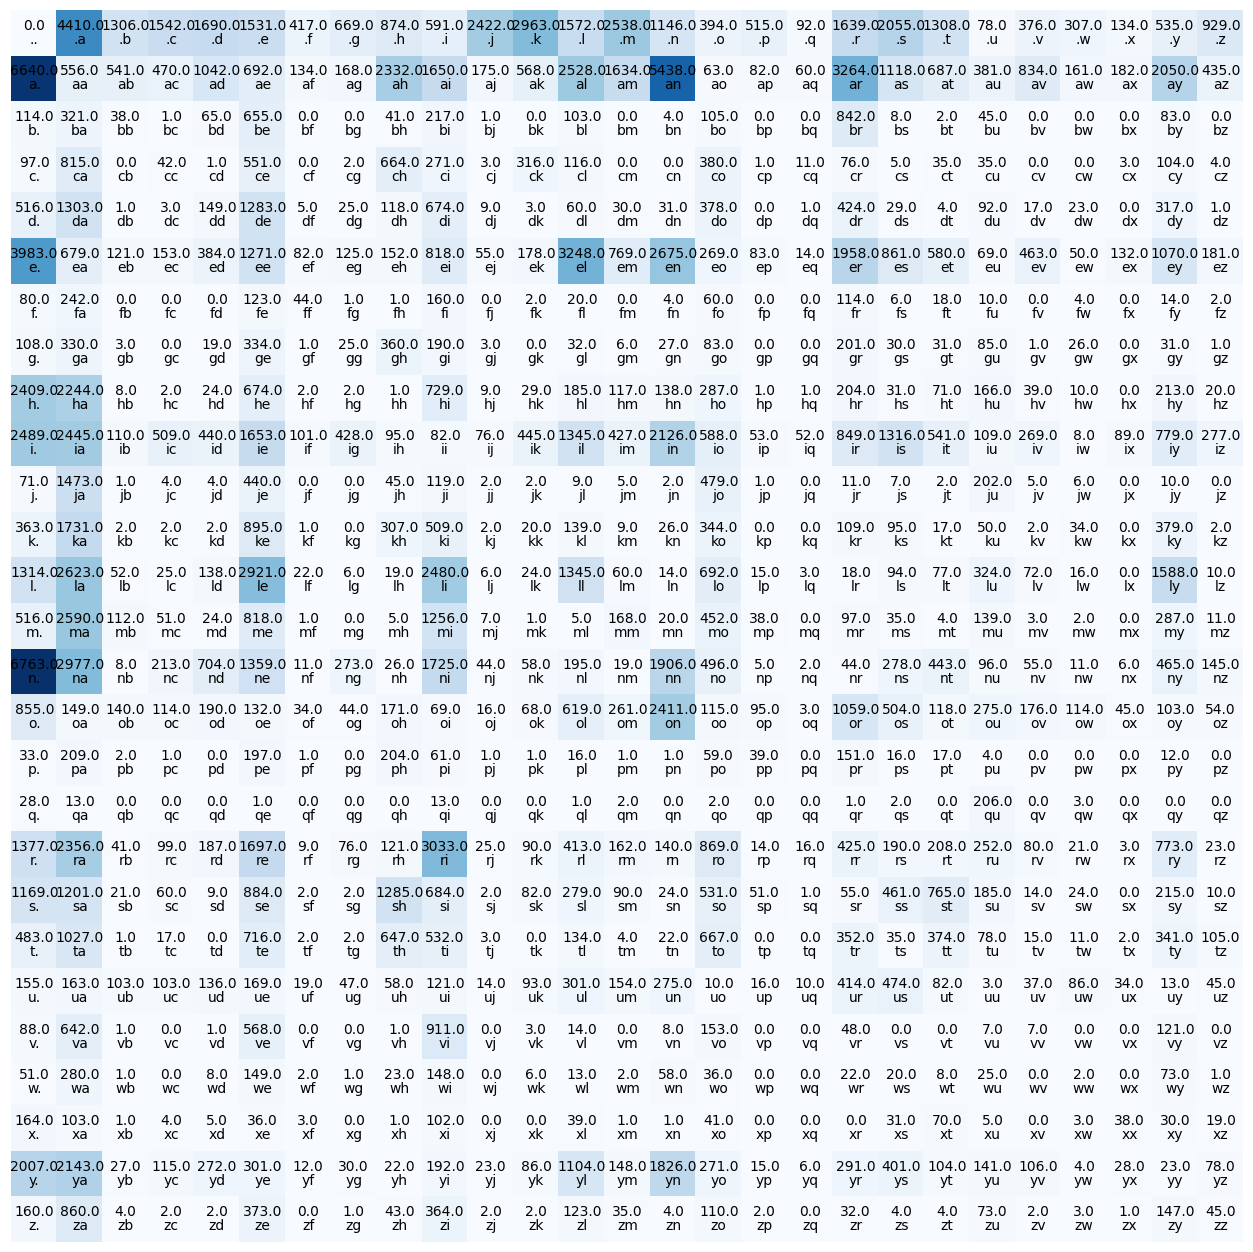

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(16,16))
plt.imshow(N,cmap="Blues")
for i in range(27):
  for j in range(27):
    chr1 = itos[i]
    chr2 = itos[j]
    chrstr = chr1 + chr2
    plt.text(j,i,chrstr,ha="center",va="top")
    plt.text(j,i,N[i,j].item(),ha="center",va="bottom")
    plt.axis('off')

In [11]:
N /= N.sum(axis=1,keepdim=True)

In [12]:
N.sum(axis=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [13]:
i = 0

In [14]:
N[0]

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [15]:
g = torch.Generator().manual_seed(7648564564)
torch.multinomial(N[0],num_samples=1,generator=g).item()

18

In [16]:
for i in range(10):
    idx = 0
    name = ""
    while True:
        p = N[idx]
        idx = torch.multinomial(p,num_samples=1,generator=g).item()
        name += itos[idx]
        if idx == 0:
            break
    print(name)

aneerian.
mayny.
beonierua.
dyavvemieca.
clirm.
jarealiasikasl.
stuble.
laan.
jo.
eriazabimez.


In [28]:
anll = 0
for name in names:
    new_name = "." + name + "."
    log_prob = 0
    for ch1,ch2 in zip(new_name[:-1],new_name[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        log_prob += torch.log(N[idx1,idx2]) # LOG LOSS
        nll = - (log_prob.item())
        anll = nll/(len(new_name)-2)
    anll += anll

In [29]:
nll

24.368385314941406

In [30]:
anl

9.747354125976562

In [31]:
import numpy as np

In [36]:
probabilities = torch.tensor(np.array([1/2,1/2]))

In [41]:
torch.multinomial(probabilities,num_samples=10000,replacement=True).sum()/10000

tensor(0.5157)